In [5]:
! pip install matplotlib seaborn scikit-learn flask

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

import requests
import json


Tamanho do conjunto de treino: 120 amostras
Tamanho do conjunto de validação: 30 amostras

Acurácia no conjunto de validação: 96.67%

Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



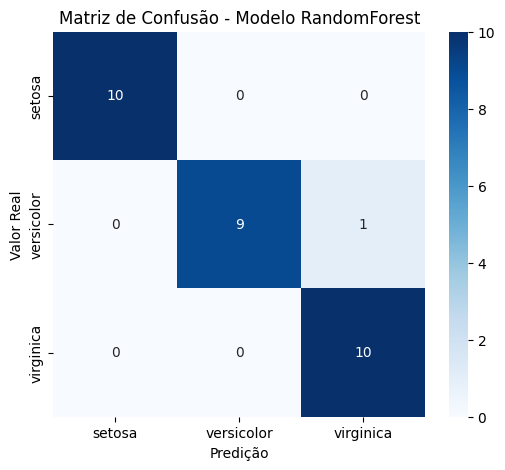

In [18]:
iris = load_iris()
X = iris.data              # features (características)
y = iris.target            # target (rótulos das classes)
target_names = iris.target_names

# treino (80%) e validação (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de validação: {len(X_val)} amostras")

# 🌳 Cria e treina o modelo de classificação
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

# 🔍 Faz previsões no conjunto de validação
y_pred = model.predict(X_val)

# 📈 Avalia o desempenho
acc = accuracy_score(y_val, y_pred)
print(f"\nAcurácia no conjunto de validação: {acc:.2%}\n")

print("Relatório de Classificação:")
print(classification_report(y_val, y_pred, target_names=target_names))

# 🧩 Matriz de Confusão
cm = confusion_matrix(y_val, y_pred)

with open("modelo_iris.pkl", "wb") as arquivo:
    pickle.dump(model, arquivo)

with open("name_labels.pkl", "wb") as arquivo:
    pickle.dump(target_names, arquivo)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Matriz de Confusão - Modelo RandomForest")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()

In [3]:
def prever_especie(valores):
    """
    Recebe um array ou lista de valores no formato:
    [comprimento_sépala, largura_sépala, comprimento_pétala, largura_pétala]
    e retorna o nome da espécie prevista.
    """
    with open("modelo_iris.pkl", "rb") as arquivo:
        modelo = pickle.load(arquivo)
    
    with open("name_labels.pkl", "rb") as arquivo:
        target_names = pickle.load(arquivo)

    valores = np.array(valores).reshape(1, -1)
    pred = modelo.predict(valores)
    especie = target_names[pred[0]]

    return especie


In [25]:
exemplo = [5.1, 3.5, 1.4, 0.2]  # setosa
resultado = prever_especie(exemplo)
resultado

np.str_('setosa')

In [7]:
exemplo = [6.2, 3.4, 5.4, 2.3]   # virginica
resultado = prever_especie(exemplo)
resultado

np.str_('virginica')

In [ ]:
# 🔹 URL da API Flask (ajuste se necessário)
url = "http://localhost:5000/invocations"

with open("name_labels.pkl", "rb") as arquivo:
    target_names = pickle.load(arquivo)

In [69]:
payload = {"inputs": [[5.1, 3.5, 1.4, 0.2]]}  # setosa

pred = requests.post(url, json=payload).json()
pred = pred['predictions']
predicted_name = target_names[pred[0]]

print(predicted_name)

setosa


In [70]:
payload = {"inputs": [[6.2, 3.4, 5.4, 2.3]]}   # virginica

pred = requests.post(url, json=payload).json()
pred = pred['predictions']
predicted_name = target_names[pred[0]]

print(predicted_name)

virginica
